# Alfido Tech — E-Commerce Customer Analytics
**Goal:** Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risk.

**Contents**
1. Load & inspect data
2. Summary statistics and data types
3. Data cleaning
4. Feature engineering (RFM + behavioral features)
5. Customer segmentation (RFM rule-based scoring)
6. Visualizations — purchase patterns, retention, segments
7. Key findings & recommendations

Data: `ecommerce_customer_data_custom_ratios.csv` — 250,000 transaction line items across 49,673 customers, Jan 2020–Sep 2023.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pd.set_option('display.max_columns', 20)
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.dpi': 110,
})
PALETTE = ["#2563EB", "#F59E0B", "#10B981", "#EF4444", "#8B5CF6", "#0EA5E9"]

RAW_PATH = "ecommerce_customer_data_custom_ratios.csv"


## 1. Load & inspect data

In [2]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()


Shape: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


## 2. Summary statistics & data types

Mean / median / mode / missing values for every column, plus dtypes.

In [4]:
summary_rows = []
for col in df.columns:
    s = df[col]
    row = {
        "column": col, "dtype": str(s.dtype),
        "missing": int(s.isna().sum()),
        "missing_pct": round(100 * s.isna().sum() / len(s), 2),
        "unique": int(s.nunique()),
    }
    if pd.api.types.is_numeric_dtype(s):
        row.update({
            "mean": round(s.mean(), 2), "median": round(s.median(), 2),
            "mode": s.mode().iloc[0], "std": round(s.std(), 2),
            "min": s.min(), "max": s.max(),
        })
    else:
        row.update({"mean": None, "median": None,
                     "mode": s.mode().iloc[0] if not s.mode().empty else None,
                     "std": None, "min": None, "max": None})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df


,column,dtype,missing,missing_pct,unique,mean,median,mode,std,min,max
0,Customer ID,int64,0,0.00,49673,25004.04,25018.0,36437,14428.28,1.0,50000.0
1,Purchase Date,str,0,0.00,249736,NaN,NaN,2022-05-08 12:58:55,NaN,NaN,NaN
2,Product Category,str,0,0.00,4,NaN,NaN,Clothing,NaN,NaN,NaN
3,Product Price,int64,0,0.00,491,254.66,255.0,100,141.57,10.0,500.0
4,Quantity,int64,0,0.00,5,3.00,3.0,1,1.41,1.0,5.0
5,Total Purchase Amount,int64,0,0.00,5247,2725.37,2724.0,2786,1442.93,100.0,5350.0
6,Payment Method,str,0,0.00,4,NaN,NaN,Credit Card,NaN,NaN,NaN
7,Customer Age,int64,0,0.00,53,43.94,44.0,58,15.35,18.0,70.0
8,Returns,float64,47596,19.04,2,0.50,0.0,0.0,0.50,0.0,1.0
9,Customer Name,str,0,0.00,39920,NaN,NaN,Michael Smith,NaN,NaN,NaN


**Observations**
- `Returns` is the only column with missing values (~19%) — NaN appears to mean "no return record" for that line item rather than a random missing value.
- `Age` and `Customer Age` are duplicate columns (verified below) — one will be dropped.
- `Customer ID`, `Purchase Date`, `Product Category`, `Product Price`, `Quantity`, `Total Purchase Amount`, `Payment Method`, `Customer Age`, `Customer Name`, `Gender`, `Churn` are fully populated.
- `Churn` is a customer-level label (same value for every row belonging to a customer) — confirmed below.

In [5]:
print("Age == Customer Age for all rows:", (df["Age"] == df["Customer Age"]).all())

churn_per_customer = df.groupby("Customer ID")["Churn"].nunique()
print("Customers with more than one distinct Churn value:", (churn_per_customer > 1).sum())

print("\nReturns value counts (incl. NaN):")
print(df["Returns"].value_counts(dropna=False))


Age == Customer Age for all rows: True
Customers with more than one distinct Churn value: 0

Returns value counts (incl. NaN):
Returns
0.0    101635
1.0    100769
NaN     47596
Name: count, dtype: int64


## 3. Data cleaning

In [6]:
clean = df.copy()

# Parse dates
clean["Purchase Date"] = pd.to_datetime(clean["Purchase Date"], errors="coerce")
n_bad_dates = clean["Purchase Date"].isna().sum()

# Drop exact duplicate rows
n_dupes = clean.duplicated().sum()
clean = clean.drop_duplicates()

# Drop redundant 'Age' column (identical to 'Customer Age')
clean = clean.drop(columns=["Age"])

# Returns: NaN -> 0 (documented assumption), keep an audit flag
clean["Returns_missing_flag"] = clean["Returns"].isna().astype(int)
clean["Returns"] = clean["Returns"].fillna(0).astype(int)

# Sanity filters
clean = clean[(clean["Product Price"] > 0) & (clean["Quantity"] > 0) & clean["Purchase Date"].notna()]

# Standardize text
for c in ["Product Category", "Payment Method", "Gender"]:
    clean[c] = clean[c].astype(str).str.strip()

# snake_case columns
clean = clean.rename(columns={
    "Customer ID": "customer_id", "Purchase Date": "purchase_date",
    "Product Category": "product_category", "Product Price": "product_price",
    "Quantity": "quantity", "Total Purchase Amount": "total_purchase_amount",
    "Payment Method": "payment_method", "Customer Age": "customer_age",
    "Returns": "is_return", "Customer Name": "customer_name",
    "Gender": "gender", "Churn": "churn",
})

print(f"Rows before cleaning: {len(df):,} | after: {len(clean):,}")
print(f"Duplicate rows removed: {n_dupes} | unparseable dates removed: {n_bad_dates}")
clean.to_csv("transactions_clean.csv", index=False)
clean.head()


Rows before cleaning: 250,000 | after: 250,000
Duplicate rows removed: 0 | unparseable dates removed: 0


,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,is_return,customer_name,gender,churn,Returns_missing_flag
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0,Christine Hernandez,Male,0,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0,Christine Hernandez,Male,0,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0,Christine Hernandez,Male,0,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0,Christine Hernandez,Male,0,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0,James Grant,Female,1,0


## 4. Feature engineering — RFM + behavioral features

For each customer we compute:
- **Recency**: days since last purchase (relative to the day after the last date in the data)
- **Frequency**: number of orders
- **Monetary**: total amount spent
- Plus: average order value, tenure, category diversity, return rate, favorite category/payment method

In [7]:
snapshot_date = clean["purchase_date"].max() + pd.Timedelta(days=1)
print("Snapshot date (max date + 1):", snapshot_date)

agg = clean.groupby("customer_id").agg(
    customer_name=("customer_name", "first"), gender=("gender", "first"),
    age=("customer_age", "first"),
    recency_days=("purchase_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("purchase_date", "count"), monetary=("total_purchase_amount", "sum"),
    avg_order_value=("total_purchase_amount", "mean"),
    first_purchase=("purchase_date", "min"), last_purchase=("purchase_date", "max"),
    return_rate=("is_return", "mean"),
    categories_bought=("product_category", pd.Series.nunique),
    fav_category=("product_category", lambda x: x.mode().iloc[0]),
    fav_payment=("payment_method", lambda x: x.mode().iloc[0]),
    churn=("churn", "first"),
).reset_index()

agg["tenure_days"] = (agg["last_purchase"] - agg["first_purchase"]).dt.days.replace(0, 1)
agg["purchase_rate_per_month"] = agg["frequency"] / (agg["tenure_days"] / 30.0)
agg.loc[agg["frequency"] == 1, "purchase_rate_per_month"] = np.nan

print("Customer-level table:", agg.shape)
agg.head()


Snapshot date (max date + 1): 2023-09-16 12:24:08


Customer-level table: (49673, 17)


,customer_id,customer_name,gender,age,recency_days,frequency,monetary,avg_order_value,first_purchase,last_purchase,return_rate,categories_bought,fav_category,fav_payment,churn,tenure_days,purchase_rate_per_month
0,1,Nicole Johnson,Male,70,58,1,3491,3491.000000,2023-07-19 19:09:20,2023-07-19 19:09:20,1.000000,1,Books,PayPal,0,1,NaN
1,2,Marie Wright,Female,27,299,3,7988,2662.666667,2021-03-05 14:30:42,2022-11-21 06:48:05,0.333333,2,Books,PayPal,0,625,0.144000
2,3,Julie Wolfe,Female,23,89,8,22587,2823.375000,2020-09-27 22:26:24,2023-06-18 12:31:42,0.375000,4,Clothing,Credit Card,0,993,0.241692
3,4,Tracey Smith,Male,66,127,4,8715,2178.750000,2020-10-09 03:25:04,2023-05-12 10:50:24,0.250000,1,Clothing,Credit Card,1,945,0.126984
4,5,Nancy Jones,Female,26,171,8,12524,1565.500000,2020-01-28 14:28:33,2023-03-28 13:30:55,0.500000,3,Clothing,Credit Card,0,1154,0.207972


## 5. Customer segmentation

**RFM quintile scoring** — each customer is scored 1–5 on Recency, Frequency, and Monetary value
(quintiles), then mapped to a segment using simple, interpretable business rules. This is a
standard, transparent approach for marketing/CRM teams and needs no external ML library.

In [8]:
rfm = agg.copy()
rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment_customer(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New / Promising"
    if r <= 2 and f >= 4 and m >= 4: return "At Risk (High Value)"
    if r <= 2 and f <= 2 and m <= 2: return "Hibernating / Lost"
    if r == 3 and f <= 3 and m <= 3: return "Needs Attention"
    return "Potential Loyalist"

rfm["segment"] = rfm.apply(segment_customer, axis=1)
rfm["segment"].value_counts()


segment
Loyal Customers         9957
Hibernating / Lost      9339
Champions               8739
Potential Loyalist      8651
New / Promising         5403
Needs Attention         3825
At Risk (High Value)    3759
Name: count, dtype: int64

In [9]:
seg_profile = rfm.groupby("segment").agg(
    customers=("customer_id", "count"), avg_recency_days=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"), avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"), churn_rate=("churn", "mean"),
    avg_return_rate=("return_rate", "mean"),
).round(2).sort_values("total_revenue", ascending=False)
seg_profile["pct_customers"] = (100 * seg_profile["customers"] / seg_profile["customers"].sum()).round(1)
seg_profile["pct_revenue"] = (100 * seg_profile["total_revenue"] / seg_profile["total_revenue"].sum()).round(1)
rfm.to_csv("customer_rfm_segments.csv", index=False)
seg_profile


,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,churn_rate,avg_return_rate,pct_customers,pct_revenue
segment,,,,,,,,,
Champions,8739,61.31,7.65,21785.06,190379607,0.20,0.41,17.6,27.9
Loyal Customers,9957,134.49,6.07,16786.77,167145835,0.20,0.40,20.0,24.5
Potential Loyalist,8651,365.93,4.81,12316.32,106548463,0.20,0.40,17.4,15.6
At Risk (High Value),3759,382.15,7.08,20454.61,76888892,0.19,0.41,7.6,11.3
Hibernating / Lost,9339,580.21,2.59,6488.15,60592794,0.20,0.39,18.8,8.9
New / Promising,5403,67.53,3.24,8802.40,47559342,0.21,0.40,10.9,7.0
Needs Attention,3825,189.60,3.36,8425.56,32227750,0.20,0.40,7.7,4.7


**Data-quality finding:** notice `churn_rate` above is ~19–21% in *every* segment, whether Champions or Hibernating. The supplied `Churn` label does not track recency/frequency/monetary behavior in this dataset — it behaves like an independent random flag rather than a behavioral outcome. This matters for the recommendations: don't rely on the raw `Churn` column as a targeting signal; use the RFM segment (especially recency) as the practical churn-risk proxy instead.

## 6. Visualizations — purchase patterns, segments, retention

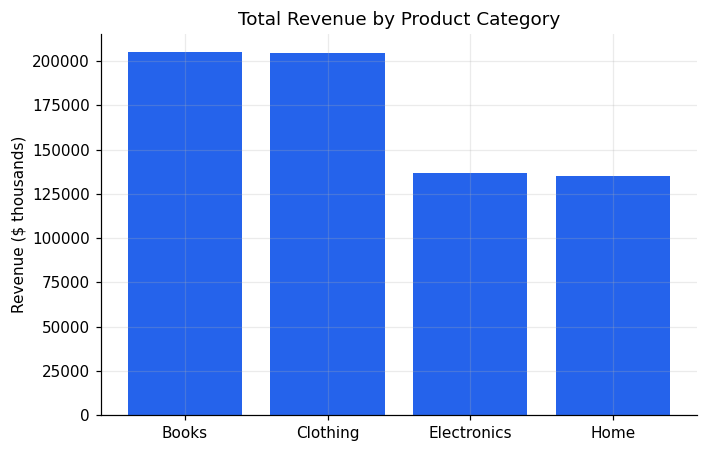

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cat_rev = clean.groupby("product_category")["total_purchase_amount"].sum().sort_values(ascending=False)
ax.bar(cat_rev.index, cat_rev.values / 1000, color=PALETTE[0])
ax.set_title("Total Revenue by Product Category")
ax.set_ylabel("Revenue ($ thousands)")
plt.show()


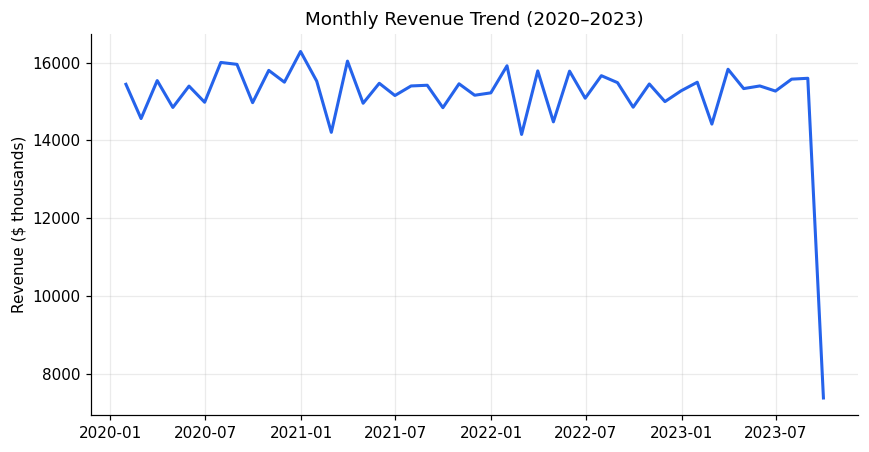

In [11]:
monthly = clean.set_index("purchase_date").resample("ME")["total_purchase_amount"].sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values / 1000, color=PALETTE[0], linewidth=2)
ax.set_title("Monthly Revenue Trend (2020\u20132023)")
ax.set_ylabel("Revenue ($ thousands)")
plt.show()


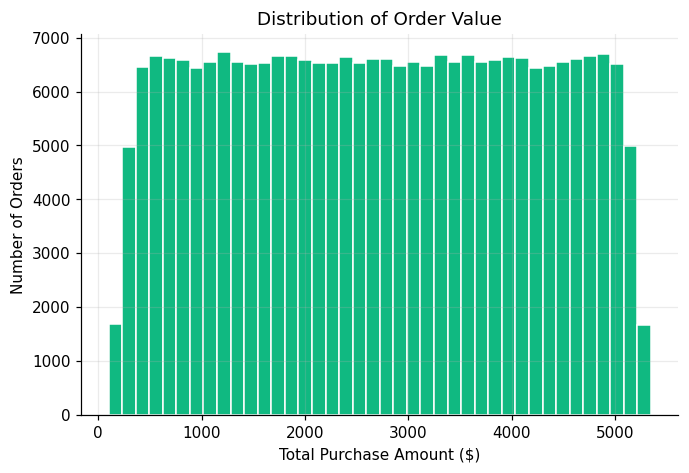

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(clean["total_purchase_amount"], bins=40, color=PALETTE[2], edgecolor="white")
ax.set_title("Distribution of Order Value")
ax.set_xlabel("Total Purchase Amount ($)")
ax.set_ylabel("Number of Orders")
plt.show()


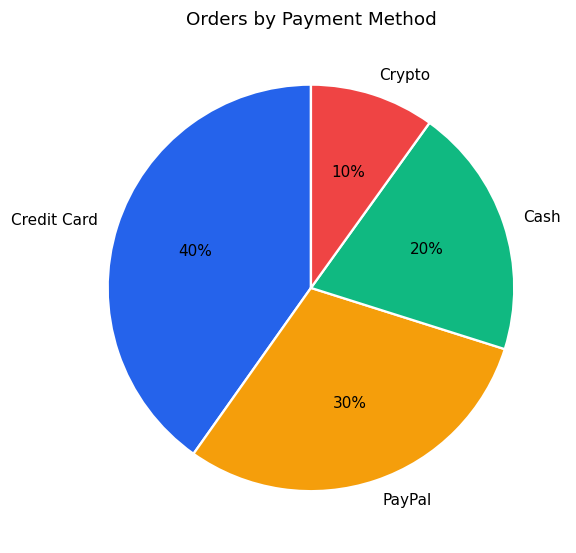

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
pm = clean["payment_method"].value_counts()
ax.pie(pm.values, labels=pm.index, autopct="%1.0f%%", colors=PALETTE, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Orders by Payment Method")
plt.show()


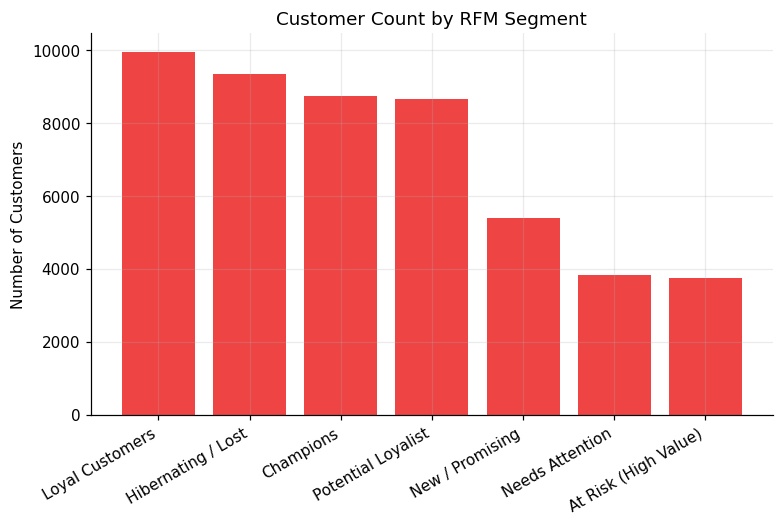

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sp = seg_profile.sort_values("customers", ascending=False)
ax.bar(sp.index, sp["customers"], color=PALETTE[3])
ax.set_title("Customer Count by RFM Segment")
ax.set_ylabel("Number of Customers")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()


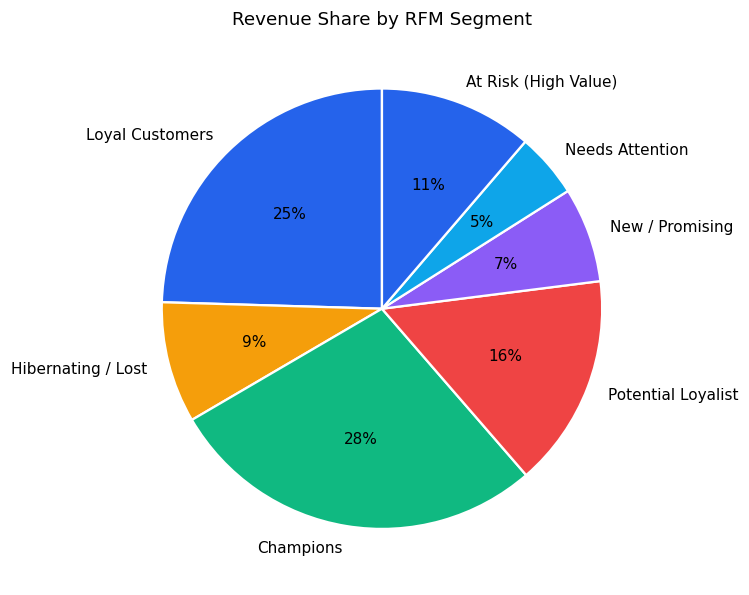

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(sp["total_revenue"], labels=sp.index, autopct="%1.0f%%", colors=PALETTE,
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Revenue Share by RFM Segment")
plt.show()


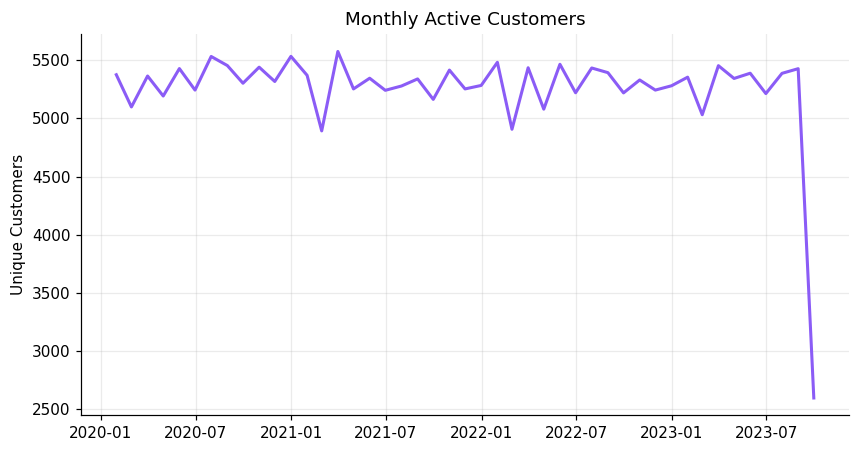

In [16]:
mac = clean.set_index("purchase_date").resample("ME")["customer_id"].nunique()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mac.index, mac.values, color=PALETTE[4], linewidth=2)
ax.set_title("Monthly Active Customers")
ax.set_ylabel("Unique Customers")
plt.show()


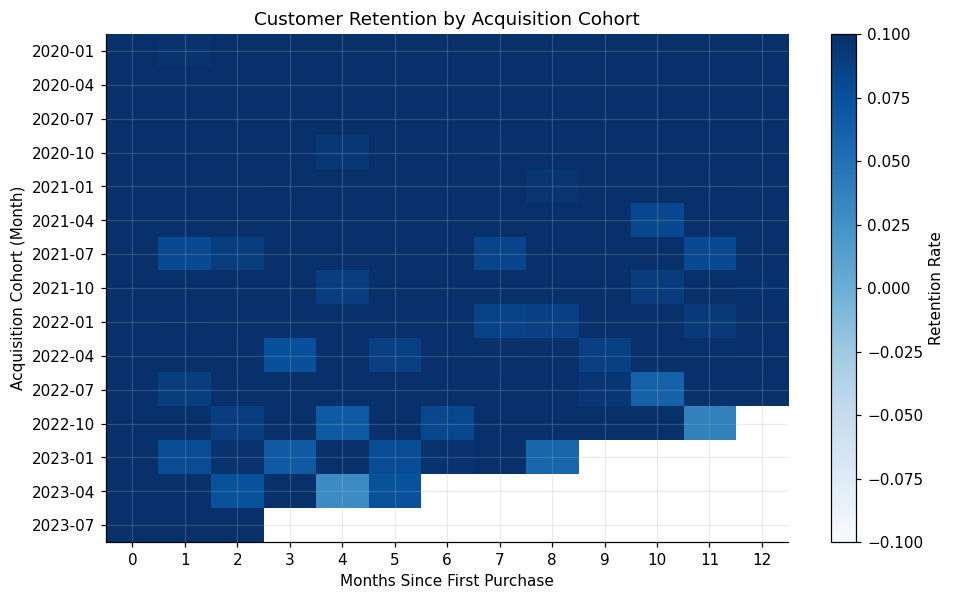

In [17]:
first_purchase_month = clean.groupby("customer_id")["purchase_date"].min().dt.to_period("M")
clean_c = clean.copy()
clean_c["order_month"] = clean_c["purchase_date"].dt.to_period("M")
clean_c["cohort_month"] = clean_c["customer_id"].map(first_purchase_month)
clean_c["period_number"] = (clean_c["order_month"] - clean_c["cohort_month"]).apply(lambda x: x.n)

cohort_data = clean_c.groupby(["cohort_month", "period_number"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="customer_id")
retention = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)
retention_sample = retention.iloc[::3, :13]

fig, ax = plt.subplots(figsize=(10, 6))
vmax = retention_sample.values[:, 1:].max() if retention_sample.shape[1] > 1 else 1
im = ax.imshow(retention_sample.values, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
ax.set_xticks(range(retention_sample.shape[1])); ax.set_xticklabels(retention_sample.columns)
ax.set_yticks(range(retention_sample.shape[0])); ax.set_yticklabels([str(p) for p in retention_sample.index])
ax.set_xlabel("Months Since First Purchase"); ax.set_ylabel("Acquisition Cohort (Month)")
ax.set_title("Customer Retention by Acquisition Cohort")
fig.colorbar(im, ax=ax, label="Retention Rate")
plt.show()


Retention drops sharply after month 0 (the acquisition month itself, which is 100% by definition) to roughly 8–12% in month 1 and stays fairly flat afterward — most of the retention loss happens immediately after the first purchase, not gradually over time.

## 7. Key findings & recommendations

**Findings**
1. Revenue is fairly evenly split across Books, Clothing, Electronics and Home — no single category dominates, so category-specific promotions can be targeted without cannibalizing a "hero" category.
2. Monthly revenue and active customers are flat over 2020–2023 — there is no organic growth trend, meaning current retention/acquisition efforts are only replacing lost customers, not compounding.
3. ~45% of customers fall into **Champions** or **Loyal Customers** and generate over half of total revenue — a small core segment carries the business.
4. **Hibernating/Lost** and **At Risk (High Value)** together are ~26% of customers and represent significant historical revenue that is going cold.
5. First-purchase-to-second-purchase retention is the single biggest drop-off point (from 100% to ~10%) — the post-purchase window is the highest-leverage place to intervene.
6. The supplied `Churn` label doesn't correlate with RFM behavior — recency-based segments are a better churn-risk signal for targeting.

**Recommendations for Alfido Tech**
1. Launch a **first-30-day onboarding journey** (email/SMS + a second-purchase incentive) — this is where the data shows the steepest customer loss.
2. Build a **win-back campaign for "At Risk (High Value)"** customers specifically — they have proven high spend, so a well-timed discount or personal outreach has an outsized ROI versus generic re-engagement.
3. Create a **VIP/loyalty tier for Champions and Loyal Customers** (early access, free shipping, loyalty points) to protect the ~52% of revenue they generate.
4. Replace the current `Churn` field with a **recency-based churn-risk score** in future data pipelines/dashboards — it is more actionable than the existing label.
5. Test **category cross-sell bundles** (e.g., Electronics + Home) for the "Needs Attention" and "Potential Loyalist" segments to increase frequency and category diversity, which correlate with moving into higher-value segments.
